# Анализ факторов, влияющих на оценки вин

**Название предмета:**  
Языки Python для анализа данных  

**Студент:**  
Кузнецов Артур Геннадьевич  

**Преподаватель:**  
Чернышева Анастасия Вадимовна

## Понимание бизнеса (Business Understanding)

### Постановка задачи

**Цель проекта** — выявить, как различные характеристики вина (страна производства, регион, сорт винограда, цена и т.д.) влияют на его оценку.

### Формулировка гипотез

1. **Цена напрямую влияет на оценку вина**: чем выше цена вина, тем выше его оценка.
2. **Страна производства имеет значение**: вина из Франции получают более высокие оценки, чем вина из других стран.
3. **Оценка вина зависит от сорта винограда**: некоторые сорта винограда чаще получают более высокие оценки.

## Начальное изучение данных (Data Understanding)

### Сбор данных

In [308]:
# Установка необходимых библиотек
!pip install dash
!pip install plotly
!pip install kaggle

In [309]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
from dash import Dash, html, dcc, Input, Output

from scipy.stats import pearsonr, f_oneway
import statsmodels.api as sm

In [310]:
# Создание каталога с именем “.kaggle”
!mkdir -p ~/.kaggle

In [311]:
# Копирование файла “kaggle.json” в созданный каталог
!cp kaggle.json ~/.kaggle/

In [312]:
# Настройка прав доступа к файлу
! chmod 600 ~/.kaggle/kaggle.json

In [313]:
# Загрузка набора данных
!kaggle datasets download zynicide/wine-reviews

Dataset URL: https://www.kaggle.com/datasets/zynicide/wine-reviews
License(s): CC-BY-NC-SA-4.0
wine-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [314]:
# Распаковка архива
!unzip wine-reviews.zip

Archive:  wine-reviews.zip
replace winemag-data-130k-v2.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: winemag-data-130k-v2.csv  
  inflating: winemag-data-130k-v2.json  
  inflating: winemag-data_first150k.csv  


Загрузка данных в DataFrame

In [315]:
# Загрузка данных в DataFrame
df = pd.read_csv('winemag-data-130k-v2.csv', index_col=0)

# Просмотр первых 5 строк
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


### Первичный анализ данных

**Размерность данных**

Проверим размерность набора данных.

In [316]:
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

Строк: 129971, Столбцов: 13


**Информация о данных**

Получим общее представление о типах данных и количестве ненулевых значений в каждом столбце.

In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  object 
 1   description            129971 non-null  object 
 2   designation            92506 non-null   object 
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  object 
 6   region_1               108724 non-null  object 
 7   region_2               50511 non-null   object 
 8   taster_name            103727 non-null  object 
 9   taster_twitter_handle  98758 non-null   object 
 10  title                  129971 non-null  object 
 11  variety                129970 non-null  object 
 12  winery                 129971 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 13.9+ MB


Статистическое описание числовых признаков

In [318]:
df.describe()

,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


**Проверка на пропущенные значения**

Посмотрим, сколько пропущенных значений в каждом столбце.

In [319]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

region_2                 79460
designation              37465
taster_twitter_handle    31213
taster_name              26244
region_1                 21247
price                     8996
country                     63
province                    63
variety                      1
description                  0
points                       0
title                        0
winery                       0
dtype: int64


**Визуализация пропущенных значений**

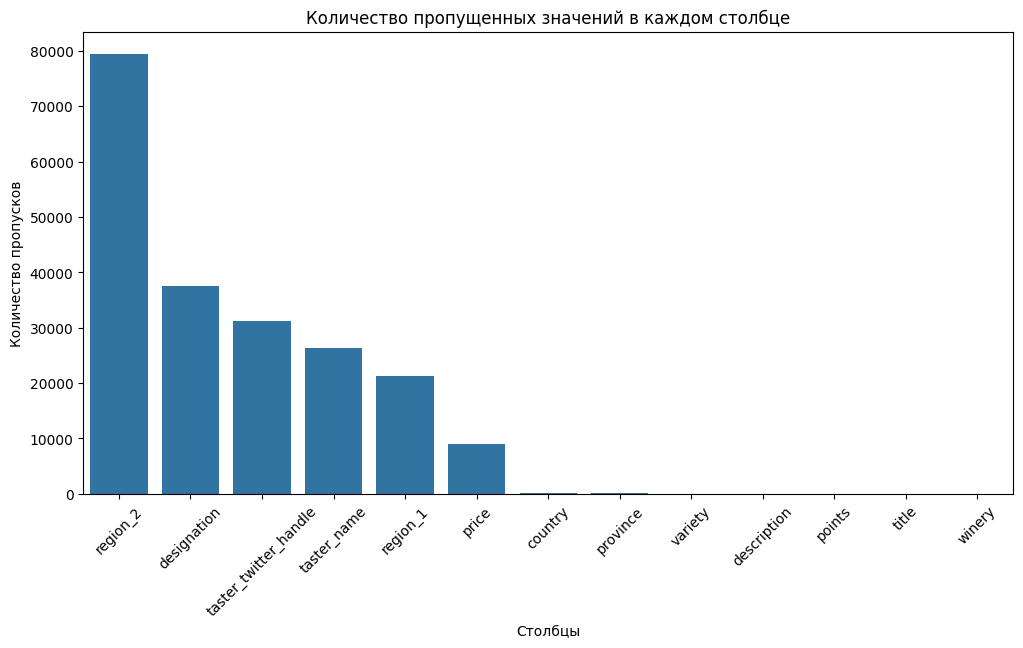

In [320]:
plt.figure(figsize=(12,6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Количество пропущенных значений в каждом столбце')
plt.xlabel('Столбцы')
plt.ylabel('Количество пропусков')
plt.xticks(rotation=45)
plt.show()

**Распределение оценок**

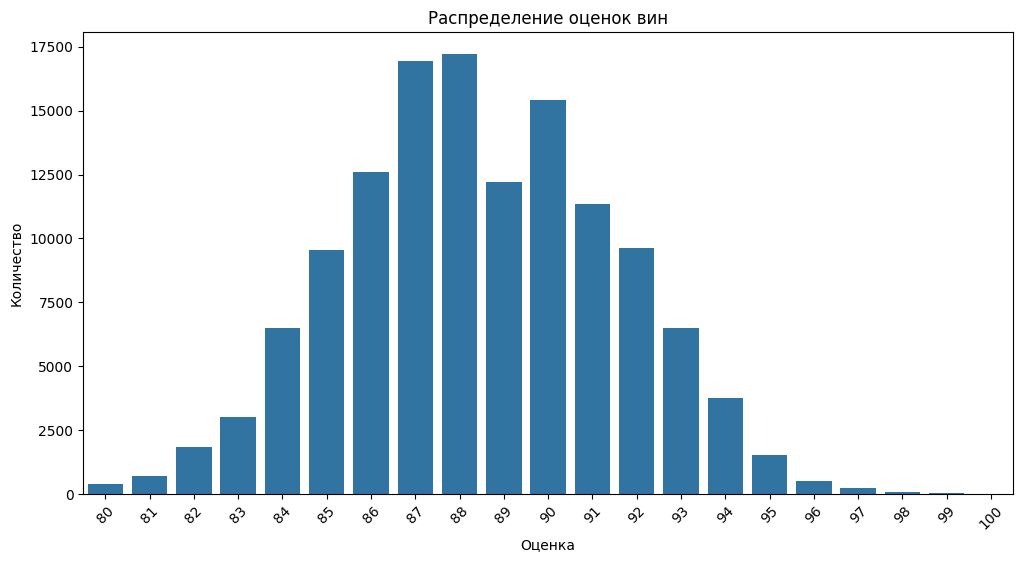

In [321]:
plt.figure(figsize=(12,6))
sns.countplot(x='points', data=df)
plt.title('Распределение оценок вин')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

**Распределение цен**

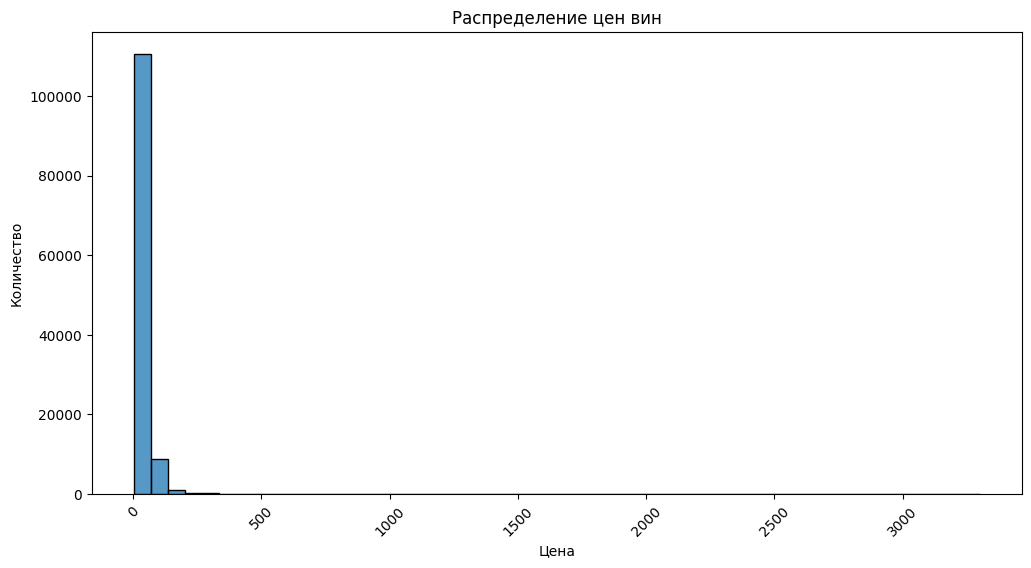

In [322]:
plt.figure(figsize=(12,6))
sns.histplot(x='price', data=df, bins=50)
plt.title('Распределение цен вин')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

**Топ 10 стран по количеству обзоров**

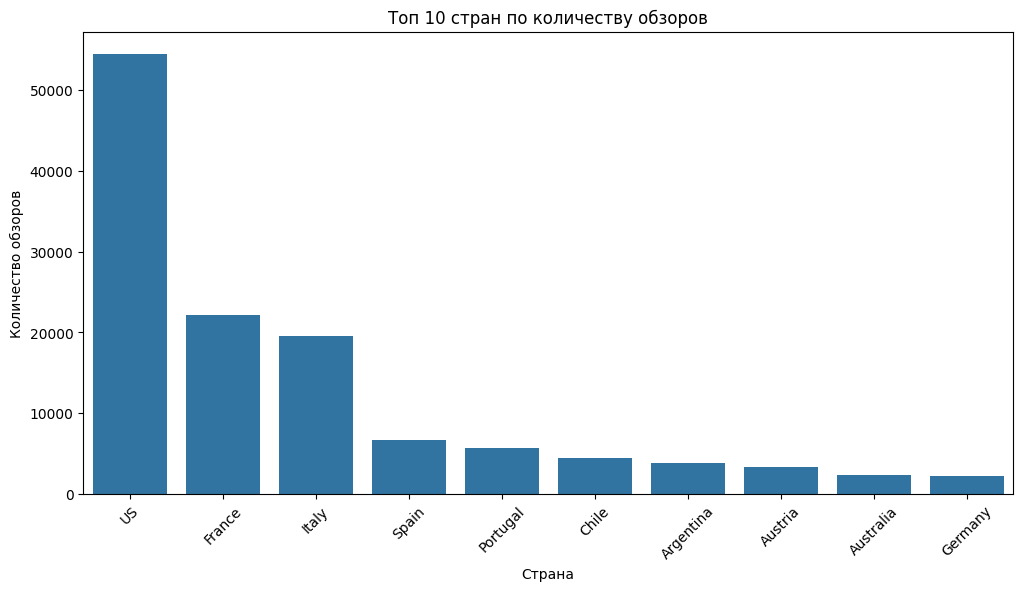

In [323]:
plt.figure(figsize=(12,6))
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Топ 10 стран по количеству обзоров')
plt.xlabel('Страна')
plt.ylabel('Количество обзоров')
plt.xticks(rotation=45)
plt.show()

**Корреляция между ценой и оценкой**

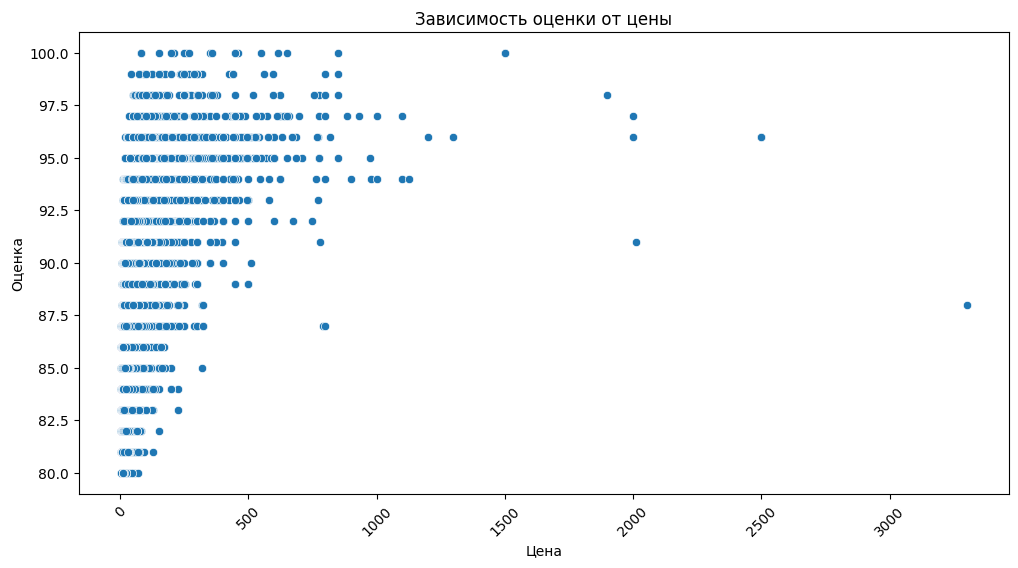

In [324]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='price', y='points', data=df)
plt.title('Зависимость оценки от цены')
plt.xlabel('Цена')
plt.ylabel('Оценка')
plt.xticks(rotation=45)
plt.show()

**Топ 10 сортов винограда по количеству обзоров**

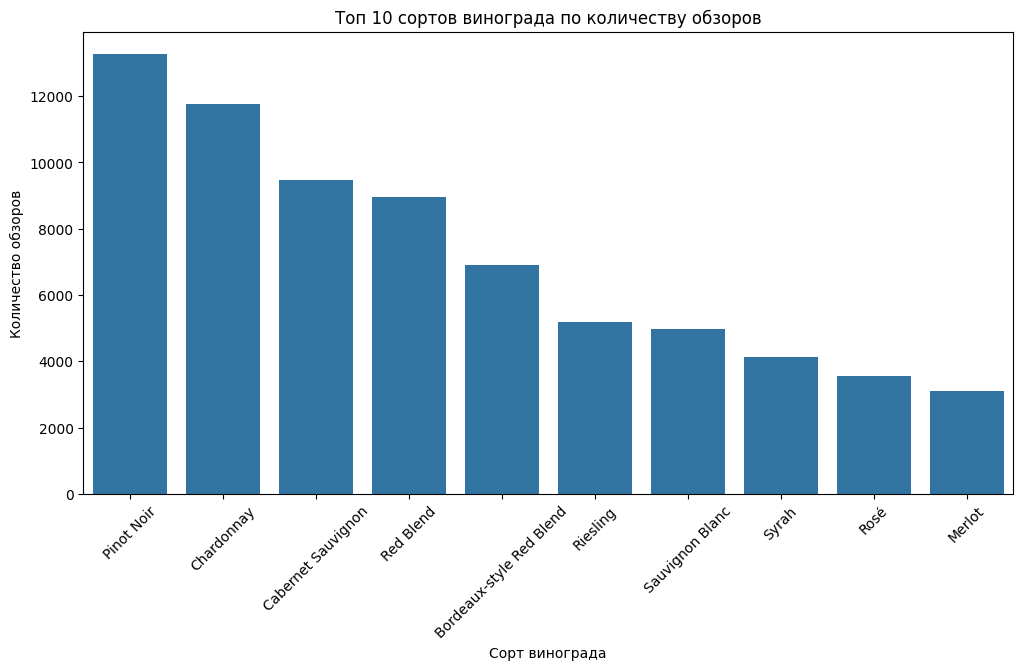

In [325]:
plt.figure(figsize=(12,6))
variety_counts = df['variety'].value_counts().head(10)
sns.barplot(x=variety_counts.index, y=variety_counts.values)
plt.title('Топ 10 сортов винограда по количеству обзоров')
plt.xlabel('Сорт винограда')
plt.ylabel('Количество обзоров')
plt.xticks(rotation=45)
plt.show()

## Подготовка данных (Data Preparation)

### Отбор данных

**Просмотр доступных столбцов**

In [326]:
df.columns

Index(['country', 'description', 'designation', 'points', 'price', 'province',
       'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title',
       'variety', 'winery'],
      dtype='object')

**Удаление ненужных столбцов**

Поскольку цель проекта не связана с данными о дегустаторах или подробными региональными данными, мы можем удалить некоторые столбцы, которые не будут полезны для нашего анализа.

Оставим только те столбцы, которые необходимы для проверки наших гипотез:

- `country` — страна производства
- `points` — оценка вина
- `price` — цена вина
- `variety` — сорт винограда

In [327]:
df = df[['country', 'points', 'price', 'variety']]

**Проверка пропущенных значений в оставшихся столбцах**

In [328]:
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

Строк: 129971, Столбцов: 4


In [329]:
df.isnull().sum()

,0
country,63
points,0
price,8996
variety,1


**Обработка пропущенных значений**

Удалим строки с пропусками в столбцах `country`, `price` и `variety`, так как они важны для наших гипотез.

In [330]:
df = df.dropna(subset=['country', 'price', 'variety'])

In [331]:
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

Строк: 120915, Столбцов: 4


**Ограничение цен**

Исключим вина с ценой более $500

In [332]:
print(f"Минимальная цена: ${df['price'].min()}, Максимальная цена: ${df['price'].max()}")

Минимальная цена: $4.0, Максимальная цена: $3300.0


In [333]:
# Фильтруем вина с ценой до $500
df = df[df['price'] <= 500]

In [334]:
print(f"Минимальная цена: ${df['price'].min()}, Максимальная цена: ${df['price'].max()}")

Минимальная цена: $4.0, Максимальная цена: $500.0


## Моделирование (Modeling)

### Гипотеза 1: Цена напрямую влияет на оценку вина

Цель: Проверить, существует ли прямая зависимость между ценой вина и его оценкой.

План действий:

- Построить диаграмму рассеяния между ценой и оценкой вина.

- Рассчитать коэффициент корреляции между ценой и оценкой.

- Построить линейную регрессионную модель и оценить ее статистическую значимость

#### Диаграмма рассеяния и корреляция

In [335]:
fig1 = px.scatter(
    df,
    x='price',
    y='points',
    trendline='ols',
    title='Зависимость оценки вина от цены',
    labels={'price': 'Цена', 'points': 'Оценка'},
    opacity=0.5
)

fig1.add_annotation(
    x=df['price'].median(),
    y=df['points'].min(),
    text=f'Медиана цены: ${df["price"].median():.2f}',
    ax=0,
    ay=-220
)

fig1.add_annotation(
    x=df['price'].mean(),
    y=df['points'].min(),
    text=f'Средняя цена: ${df["price"].mean():.2f}',
    ax=0,
    ay=-260
)

fig1.show()

Линия тренда показывает положительную связь между ценой и оценкой вина. Это означает, что при увеличении цены оценка, в среднем, растет. Однако наклон линии тренда небольшой, что указывает на слабую зависимость.

#### Расчет коэффициента корреляции Пирсона

In [336]:
corr_coef, p_value = pearsonr(df['price'], df['points'])
print(f"Коэффициент корреляции Пирсона между ценой и оценкой: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")

Коэффициент корреляции Пирсона между ценой и оценкой: 0.4956
P-value: 0.0000e+00


Коэффициент корреляции Пирсона 0.4956 указывает на умеренную положительную связь между ценой и оценкой вина. Статистически значимое значение p-value 0 подтверждает, что эта связь не случайна.

#### Линейная регрессия

In [337]:
X = sm.add_constant(df['price'])
y = df['points']

# Построение модели OLS
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 points   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                 3.933e+04
Date:                Sun, 01 Dec 2024   Prob (F-statistic):               0.00
Time:                        16:43:06   Log-Likelihood:            -2.8871e+05
No. Observations:              120824   AIC:                         5.774e+05
Df Residuals:                  120822   BIC:                         5.774e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         86.7636      0.011   7696.003      0.0

Уравнение модели: points = β0 + β1 * price

β0 (const): это пересечение с осью Y, базовая оценка при цене 0. Базовая оценка равна 86.7636 баллов.

β1 (price): наклон линии, показывает изменение оценки при увеличении цены на 1 доллар. В нашем случае цена меняется на 0.0476.

Значение $R^2$ = 0.2456 означает, что только 24.56% вариации оценок объясняется ценой. Это указывает на то, что значительная часть оценки определяется другими факторами.

#### Вывод

Цена оказывает статистически значимое, но слабое влияние на оценку вина. Более дорогие вина в среднем получают более высокие оценки, но эта зависимость не абсолютна, и цена не является основным фактором, определяющим качество.

### Гипотеза 2: Страна производства имеет значение

Цель: Проверить, влияет ли страна производства вина на его оценку.

План действий:

- Построить график распределения оценок по странам.
- Сравнить средние оценки вин из разных стран.
- Провести ANOVA-тест для проверки статистической значимости различий между странами.

**Подготовка данных**

Выберем страны с достаточным количеством обзоров для статистической значимости.

In [338]:
# Количество оценок для каждой страны
country_counts = df['country'].value_counts()
print(country_counts)

# Отбираем страны с 100 и более обзорами
selected_countries = country_counts[country_counts >= 100].index.tolist()
print(selected_countries)

country
US                        54260
France                    17722
Italy                     16905
Spain                      6570
Portugal                   4868
Chile                      4415
Argentina                  3756
Austria                    2798
Australia                  2290
Germany                    2113
New Zealand                1378
South Africa               1293
Israel                      489
Greece                      461
Canada                      254
Hungary                     144
Bulgaria                    141
Romania                     120
Uruguay                     109
Turkey                       90
Georgia                      84
Slovenia                     80
Croatia                      71
Mexico                       70
England                      69
Moldova                      59
Brazil                       47
Lebanon                      35
Morocco                      28
Peru                         16
Ukraine                      14


#### График распределения оценок по странам

In [339]:
df_selected_countries = df[df['country'].isin(selected_countries)].copy()

# Считаем средние оценки для каждой страны
country_means = df_selected_countries.groupby('country')['points'].mean().sort_values(ascending=False)

# Упорядочиваем страны по средней оценке
sorted_countries = country_means.index.tolist()

# Создаём словарь для добавления средней оценки к названию страны
country_labels = {country: f"{country} ({mean:.2f})" for country, mean in country_means.items()}

# Построение скрипичного графика
fig2 = px.violin(
    df_selected_countries,
    x='country',
    y='points',
    category_orders={'country': sorted_countries},
    title='Распределение оценок вин по странам',
    labels={'country': 'Страна', 'points': 'Оценка'}
)

# Обновляем оси графика с учётом средних оценок
fig2.update_xaxes(ticktext=list(country_labels.values()), tickvals=sorted_countries)
fig2.update_layout(title_x=0.5, xaxis_tickangle=-45)
fig2.show()

График подчеркивает, что распределение оценок варьируется не только по среднему значению, но и по ширине разброса.

Австрия (90.19) и Германия (89.82) демонстрируют высокие средние оценки, а также узкий диапазон значений, что указывает на стабильное высокое качество вин.

Вина из Румынии (86.40) и Чили (86.50) имеют самые низкие средние оценки, а также умеренный разброс, что свидетельствует о более скромном уровне качества в сравнении с лидерами.

#### Статистический анализ

In [340]:
# Подготовка данных для ANOVA
groups = [df_selected_countries[df_selected_countries['country'] == country]['points'] for country in selected_countries]

# Выполнить ANOVA
f_stat, p_value = f_oneway(*groups)

print(f"F-статистика: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

F-статистика: 343.1409
P-value: 0.0000e+00


Высокая F-статистика указывает на наличие значительных различий между группами (странами).

Чрезвычайно низкое значение p-value (меньше 0.05) подтверждает статистическую значимость различий в средних оценках вин между странами.

Таким образом, результаты ANOVA подчеркивают, что страна производства действительно является важным фактором, влияющим на оценку вина.

#### **Вывод**

Как графический, так и статистический анализ убедительно показывают, что страна производства оказывает влияние на оценку вина. Следовательно, гипотеза, что страна производства имеет значение, подтверждается.

### Гипотеза 3: Оценка вина зависит от сорта винограда

Цель: Проверить, влияют ли разные сорта винограда на оценку вина.

План действий:

- Построить график распределения оценок по сортам винограда.
- Сравнить средние оценки вин из разных сортов винограда.
- Провести ANOVA-тест для проверки статистической значимости различий между сортами.

**Подготовка данных**

Выберем сорта с 1000 и более обзорами.

In [341]:
# Считаем количество обзоров для каждого сорта винограда
variety_counts = df['variety'].value_counts()
print(variety_counts)

# Отбираем сорта с 1000 и более обзорами
selected_varieties = variety_counts[variety_counts >= 1000].index.tolist()
print(selected_varieties)

variety
Pinot Noir                  12773
Chardonnay                  11061
Cabernet Sauvignon           9381
Red Blend                    8466
Bordeaux-style Red Blend     5325
                            ...  
Orangetraube                    1
Riesling-Chardonnay             1
Žilavka                         1
Pinotage-Merlot                 1
Bobal-Cabernet Sauvignon        1
Name: count, Length: 691, dtype: int64
['Pinot Noir', 'Chardonnay', 'Cabernet Sauvignon', 'Red Blend', 'Bordeaux-style Red Blend', 'Riesling', 'Sauvignon Blanc', 'Syrah', 'Rosé', 'Merlot', 'Zinfandel', 'Malbec', 'Sangiovese', 'Nebbiolo', 'Portuguese Red', 'White Blend', 'Sparkling Blend', 'Tempranillo', 'Rhône-style Red Blend', 'Pinot Gris', 'Cabernet Franc', 'Champagne Blend', 'Grüner Veltliner', 'Pinot Grigio']


#### График распределения оценок

In [342]:
df_selected_varieties = df[df['variety'].isin(selected_varieties)].copy()

# Считаем средние оценки для каждого сорта
variety_means = df_selected_varieties.groupby('variety')['points'].mean().sort_values(ascending=False)

# Упорядочиваем сорта по средней оценке
sorted_varieties = variety_means.index.tolist()

# Создаём словарь для добавления средней оценки к названию сорта
variety_labels = {variety: f"{variety} ({mean:.2f})" for variety, mean in variety_means.items()}

# Обновляем данные и строим график
fig3 = px.violin(
    df_selected_varieties,
    x='variety',
    y='points',
    category_orders={'variety': sorted_varieties},
    title='Распределение оценок по сортам винограда',
    labels={'variety': 'Сорт винограда', 'points': 'Оценка'}
)

# Обновляем оси графика с учётом средних оценок
fig3.update_xaxes(ticktext=list(variety_labels.values()), tickvals=sorted_varieties)
fig3.update_layout(title_x=0.5, xaxis_tickangle=-45)
fig3.show()

Сортировка по средним значениям позволяет легко увидеть, какие сорта более высоко оцениваются в среднем.

#### Статистический анализ

In [343]:
# Подготовка данных для ANOVA
groups = [df_selected_varieties[df_selected_varieties['variety'] == variety]['points'] for variety in selected_varieties]

# Проведение ANOVA
f_stat, p_value = f_oneway(*groups)

print(f"F-статистика: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

F-статистика: 306.0571
P-value: 0.0000e+00


Эти результаты подтверждают, что между средними оценками различных сортов винограда существуют статистически значимые различия. Низкое значение p-value (меньше 0.05) свидетельствует о том, что влияние сорта винограда на оценку вина нельзя считать случайным.

#### Вывод

Гипотеза подтверждена. Сорт винограда статистически значимо влияет на оценку вина. Это подтверждается как визуальным анализом (график распределения оценок), так и результатами ANOVA, которые показывают высокую значимость различий между сортами.

## Оценка (Evaluation)

### Анализ результатов

**Гипотеза 1: Цена напрямую влияет на оценку вина**

- Диаграмма рассеяния с трендовой линией показала слабую положительную зависимость между ценой и оценкой.
- Коэффициент корреляции Пирсона (0.4956) указывает на умеренную положительную связь между ценой и оценкой. Эта связь статистически значима (p-value ≈ 0).
- Линейная регрессия подтвердила, что увеличение цены статистически значимо связано с ростом оценки, но объясняет только 24.56% вариации ($R^2$ = 0.2456).
- **Вывод:** Цена оказывает влияние на оценку, но не является основным фактором.

**Гипотеза 2: Страна производства имеет значение**

- График распределения оценок по странам показал различия как в средних оценках, так и в разбросе оценок между странами.
- ANOVA-тест выявил статистически значимые различия между средними оценками вин из разных стран (F-статистика = 343.1409, p-value ≈ 0).
- **Вывод:** Страна производства оказывает влияние на оценку вина.

**Гипотеза 3: Оценка вина зависит от сорта винограда**

- График распределения оценок по сортам винограда показал, что различные сорта имеют разные средние оценки и разбросы.
- ANOVA-тест подтвердил, что между средними оценками сортов винограда существуют статистически значимые различия (F-статистика = 306.0571, p-value ≈ 0).
- **Вывод:** Сорт винограда оказывает влияние на оценку вина.

## Внедрение (Deployment)

### Создание дашборда

Мы создадим интерактивный дашборд с использованием Dash, который позволит пользователям взаимодействовать с данными через фильтры и вкладки.

In [344]:
# Инициализация приложения Dash
app = Dash(__name__)

In [345]:
# Создание layout приложения
app.layout = html.Div([
    html.H1("Анализ факторов, влияющих на оценки вин", style={'textAlign': 'center'}),

    dcc.Tabs([
        # Вкладка 1: Цена и оценка
        dcc.Tab(label='Цена и оценка', children=[
            html.Div([
                html.H2("График зависимости оценки от цены"),
                dcc.Graph(
                    id='price-points-scatter',
                    figure=px.scatter(
                        df,
                        x='price',
                        y='points',
                        trendline='ols',
                        title='Зависимость оценки вина от цены',
                        labels={'price': 'Цена', 'points': 'Оценка'},
                        opacity=0.5
                    ).update_traces(marker=dict(size=6, opacity=0.7))
                )
            ])
        ]),

        # Вкладка 2: Страна производства
        dcc.Tab(label='Страна производства', children=[
            html.Div([
                html.H2("Распределение оценок по странам"),
                dcc.Dropdown(
                    id='country-dropdown',
                    options=[{'label': f"{country} ({df_selected_countries['country'].value_counts()[country]})",
                              'value': country} for country in selected_countries],
                    value=selected_countries,
                    multi=True,
                    placeholder='Выберите страны'
                ),
                dcc.Graph(id='country-points-graph')
            ])
        ]),

        # Вкладка 3: Сорт винограда
        dcc.Tab(label='Сорт винограда', children=[
            html.Div([
                html.H2("Распределение оценок по сортам винограда"),
                dcc.Dropdown(
                    id='variety-dropdown',
                    options=[{'label': f"{variety} ({df_selected_varieties['variety'].value_counts()[variety]})",
                              'value': variety} for variety in selected_varieties],
                    value=selected_varieties,
                    multi=True,
                    placeholder='Выберите сорта винограда'
                ),
                dcc.Graph(id='variety-points-graph')
            ])
        ])
    ])
])

In [346]:
# Коллбэк для обновления графика по странам
@app.callback(
    Output('country-points-graph', 'figure'),
    Input('country-dropdown', 'value')
)
def update_country_graph(selected_countries):
    filtered_df = df_selected_countries[df_selected_countries['country'].isin(selected_countries)]

    # Пересчет средних оценок
    country_means = filtered_df.groupby('country')['points'].mean().sort_values(ascending=False)
    sorted_countries = country_means.index.tolist()
    country_labels = {country: f"{country} ({mean:.2f})" for country, mean in country_means.items()}

    # Построение графика
    fig = px.violin(
        filtered_df,
        x='country',
        y='points',
        category_orders={'country': sorted_countries},
        title='Распределение оценок вин по выбранным странам',
        labels={'country': 'Страна', 'points': 'Оценка'}
    )

    # Обновление меток оси X
    fig.update_xaxes(ticktext=list(country_labels.values()), tickvals=sorted_countries)
    fig.update_layout(title_x=0.5, xaxis_tickangle=-45)
    return fig

In [347]:
# Коллбэк для обновления графика по сортам винограда
@app.callback(
    Output('variety-points-graph', 'figure'),
    Input('variety-dropdown', 'value')
)
def update_variety_graph(selected_varieties):
    filtered_df = df_selected_varieties[df_selected_varieties['variety'].isin(selected_varieties)]

    # Пересчет средних оценок
    variety_means = filtered_df.groupby('variety')['points'].mean().sort_values(ascending=False)
    sorted_varieties = variety_means.index.tolist()
    variety_labels = {variety: f"{variety} ({mean:.2f})" for variety, mean in variety_means.items()}

    # Построение графика
    fig = px.violin(
        filtered_df,
        x='variety',
        y='points',
        category_orders={'variety': sorted_varieties},
        title='Распределение оценок по выбранным сортам винограда',
        labels={'variety': 'Сорт винограда', 'points': 'Оценка'}
    )

    # Обновление меток оси X
    fig.update_xaxes(ticktext=list(variety_labels.values()), tickvals=sorted_varieties)
    fig.update_layout(title_x=0.5, xaxis_tickangle=-45)
    return fig

In [348]:
# Запуск приложения
if __name__ == '__main__':
    app.run_server(debug=True)

<IPython.core.display.Javascript object>

## Выводы

В ходе исследования были проверены три гипотезы, связанные с факторами, влияющими на оценку вин. Основные выводы:

Цена оказывает влияние на оценку, но его сила невелика. Это подтверждается низким значением $R^2$ линейной регрессии.
Страна производства значимо влияет на оценку вина. Различия между странами статистически значимы, и некоторые страны (например, Австрия и Германия) стабильно получают высокие оценки.
Сорт винограда также оказывает влияние на оценку. ANOVA-тест показал, что между сортами существуют значительные различия в средних оценках.
Рекомендации:

Потребители могут использовать результаты анализа для выбора вина, учитывая страну производства и сорт винограда.
Производителям стоит уделить внимание популярным и высоко оцениваемым сортам винограда, а также странам, которые ассоциируются с высоким качеством.